## **02. The North Face: Modélisation**

**Projet** : Unsupervised Machine Learning pour le e-commerce The North Face  
**Objectif** : Clustering, système de recommandation et topic modeling

**Plan de ce notebook**
- Chargement des données prétraitées
- **Clustering - Baseline KMeans**
- **Clustering - DBSCAN (modèle amélioré)**
- Comparaison KMeans vs DBSCAN
- **Système de Recommandation**
- **Topic Modeling - LSA (TruncatedSVD)**
- Comparaison globale & Conclusion

In [1]:
import pandas as pd
import numpy as np
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

from sklearn.cluster import DBSCAN, KMeans
from sklearn.decomposition import TruncatedSVD
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
from wordcloud import WordCloud

import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12
sns.set_style('whitegrid')

output_image_path = '../outputs/images'
output_data_path = '../outputs/data'
output_models_path = '../outputs/models'

### **1. Chargement des données prétraitées**

In [2]:
# Charger le DataFrame nettoyé
df = pd.read_csv(f'{output_data_path}/cleaned_data.csv')

# Charger les artifacts TF-IDF
with open(f'{output_models_path}/tfidf_artifacts.pkl', 'rb') as f:
    artifacts = pickle.load(f)

tfidf_matrix = artifacts['tfidf_matrix']
tfidf_vectorizer = artifacts['tfidf_vectorizer']
feature_names = artifacts['feature_names']
custom_stop_words = artifacts['custom_stop_words']

print(f"Données chargées : {df.shape[0]} produits")
print(f"Matrice TF-IDF : {tfidf_matrix.shape}")
print(f"Features : {len(feature_names)}")

Données chargées : 500 produits
Matrice TF-IDF : (500, 5000)
Features : 5000


### **2. Clustering - Baseline : KMeans**

KMeans est le modèle de référence en clustering. On l'utilise comme **baseline** avant d'essayer d'autre modele.

#### **2.1. Methode de coude + Silhouette**

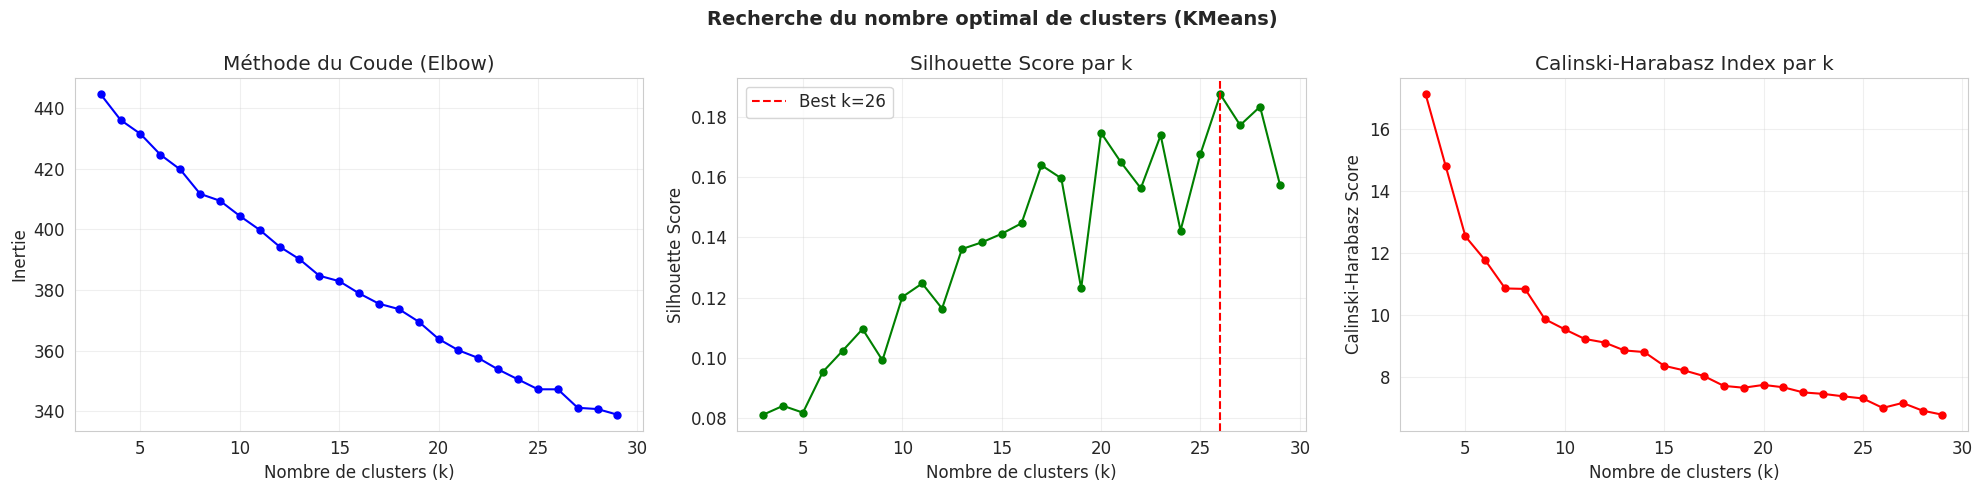

Meilleur k par Silhouette : 26 (score = 0.1877)
Meilleur k par Calinski-Harabasz : 3


In [3]:
# Recherche du nombre optimal de clusters (Elbow + Silhouette)

K_range = range(3, 30)
inertias = []
silhouette_scores = []
calinski_scores = []

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10, max_iter=300)
    labels = km.fit_predict(tfidf_matrix)
    inertias.append(km.inertia_)
    silhouette_scores.append(silhouette_score(tfidf_matrix, labels, metric='cosine', sample_size=min(300, len(df))))
    calinski_scores.append(calinski_harabasz_score(tfidf_matrix.toarray(), labels)) # variance ratio criterion

fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# Elbow
axes[0].plot(list(K_range), inertias, 'b-o', markersize=5)
axes[0].set_xlabel('Nombre de clusters (k)')
axes[0].set_ylabel('Inertie')
axes[0].set_title('Méthode du Coude (Elbow)')
axes[0].grid(True, alpha=0.3)

# Silhouette
axes[1].plot(list(K_range), silhouette_scores, 'g-o', markersize=5)
axes[1].set_xlabel('Nombre de clusters (k)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Score par k')
axes[1].grid(True, alpha=0.3)

best_k_sil = list(K_range)[np.argmax(silhouette_scores)]
axes[1].axvline(best_k_sil, color='red', linestyle='--', label=f'Best k={best_k_sil}')
axes[1].legend()

# Calinski-Harabasz
axes[2].plot(list(K_range), calinski_scores, 'r-o', markersize=5)
axes[2].set_xlabel('Nombre de clusters (k)')
axes[2].set_ylabel('Calinski-Harabasz Score')
axes[2].set_title('Calinski-Harabasz Index par k')
axes[2].grid(True, alpha=0.3)

plt.suptitle('Recherche du nombre optimal de clusters (KMeans)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()
fig.savefig(f'{output_image_path}/04_kmeans_elbow_silhouette_calinski.png')

print(f"Meilleur k par Silhouette : {best_k_sil} (score = {max(silhouette_scores):.4f})")
best_k_cal = list(K_range)[np.argmax(calinski_scores)]
print(f"Meilleur k par Calinski-Harabasz : {best_k_cal}")

#### **2.2. Entraînement du modèle KMeans**

In [4]:
# Choisir k basé sur le silhouette score (dans la plage 10-20 du projet)
valid_k_range = [(k, s) for k, s in zip(K_range, silhouette_scores) if 10 <= k <= 20]
best_k = max(valid_k_range, key=lambda x: x[1])[0] if valid_k_range else best_k_sil

print(f"k retenu : {best_k}")

# Entraîner le modèle final
kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=20, max_iter=500)
df['cluster_kmeans'] = kmeans.fit_predict(tfidf_matrix)

print(f"\nDistribution des clusters KMeans :")
print(df['cluster_kmeans'].value_counts().sort_index())

# Métriques
sil_km = silhouette_score(tfidf_matrix, df['cluster_kmeans'], metric='cosine', sample_size=min(300, len(df)))
cal_km = calinski_harabasz_score(tfidf_matrix.toarray(), df['cluster_kmeans'])
db_km = davies_bouldin_score(tfidf_matrix.toarray(), df['cluster_kmeans'])

print(f"\nMétriques KMeans (k={best_k}) :")
print(f"Silhouette Score : {sil_km:.4f}  (plus haut = mieux, [-1, 1])")
print(f"Calinski-Harabasz: {cal_km:.4f}  (plus haut = mieux)")
print(f"Davies-Bouldin : {db_km:.4f}  (plus bas = mieux)")

k retenu : 20

Distribution des clusters KMeans :
cluster_kmeans
0     55
1     47
2     15
3     15
4     18
5      9
6     58
7     33
8     32
9     25
10     6
11    31
12    17
13     8
14    20
15     8
16    31
17    12
18    51
19     9
Name: count, dtype: int64

Métriques KMeans (k=20) :
Silhouette Score : 0.1363  (plus haut = mieux, [-1, 1])
Calinski-Harabasz: 7.7801  (plus haut = mieux)
Davies-Bouldin : 3.2067  (plus bas = mieux)


#### **2.3 Analyse des clusters KMeans - Top mots**

In [5]:
for cid in sorted(df['cluster_kmeans'].unique()):
    texts = ' '.join(df[df['cluster_kmeans'] == cid]['clean_description'])
    words = [w for w in texts.split() if w not in custom_stop_words and len(w) > 2]
    top = Counter(words).most_common(8)
    top_str = ', '.join([f"{w}({c})" for w, c in top])
    count = (df['cluster_kmeans'] == cid).sum()
    print(f"Cluster {cid:2d} ({count:3d} produits) : {top_str}")

Cluster  0 ( 55 produits) : shirt(133), organic(112), thread(110), recycle(110), tap(102), shoulder(102), seam(102), print(97)
Cluster  1 ( 47 produits) : recycle(76), sun(70), pocket(65), protection(57), dry(56), thread(53), water(42), upf(41)
Cluster  2 ( 15 produits) : recycle(60), control(37), capilene(32), fast(31), gladiodor(31), natural(31), odor(31), panel(30)
Cluster  3 ( 15 produits) : merino(100), recycle(72), wool(60), wash(60), skin(49), dry(47), odor(44), softness(31)
Cluster  4 ( 18 produits) : organic(60), pocket(51), recycle(47), thread(36), button(26), jean(26), cargo(23), closure(23)
Cluster  5 (  9 produits) : pocket(27), water(27), recycle(26), shell(25), dwr(21), durable(20), finish(19), repellent(18)
Cluster  6 ( 58 produits) : pocket(209), recycle(147), thread(112), durable(91), water(89), short(86), dwr(79), finish(75)
Cluster  7 ( 33 produits) : pocket(174), strap(100), water(94), mesh(91), shoulder(72), zipper(70), polyurethane(61), durable(52)
Cluster  8 ( 3

### **3. Clustering - DBSCAN** 

DBSCAN est plus adapté aux données textuelles car :
- Il utilise la **distance cosinus** (plus pertinente que l'euclidienne)
- Il détecte automatiquement les **outliers** (produits atypiques)
- Il **ne requiert pas de fixer k** à l'avance

#### **3.1 Recherche des hyperparamètres (eps, min_samples)**

In [6]:
# Grid search sur eps et min_samples
print("Recherche des meilleurs hyperparamètres DBSCAN...")
results = []

for eps in np.arange(0.3, 0.95, 0.05):
    for min_samples in [2, 3, 4, 5, 6]:
        db = DBSCAN(eps=eps, min_samples=min_samples, metric='cosine')
        labels = db.fit_predict(tfidf_matrix)
        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        n_outliers = (labels == -1).sum()
        outlier_pct = n_outliers / len(labels) * 100
        
        if 8 <= n_clusters <= 30 and outlier_pct < 40:
            # Calculer silhouette sur les non-outliers
            mask = labels != -1
            if mask.sum() > n_clusters and n_clusters > 1:
                sil = silhouette_score(tfidf_matrix[mask], labels[mask], metric='cosine')
            else:
                sil = 0
            
            score = n_clusters * (1 - outlier_pct/100) * (1 + sil)
            results.append({
                'eps': round(eps, 2), 'min_samples': min_samples,
                'n_clusters': n_clusters, 'n_outliers': n_outliers,
                'outlier_pct': round(outlier_pct, 1),
                'silhouette': round(sil, 4),
                'score': round(score, 2)
            })

results_df = pd.DataFrame(results).sort_values('score', ascending=False)
print("Top 15 configurations :")
print(results_df.head(15).to_string(index=False))

Recherche des meilleurs hyperparamètres DBSCAN...
Top 15 configurations :
 eps  min_samples  n_clusters  n_outliers  outlier_pct  silhouette  score
0.75            2          29          15          3.0      0.1354  31.94
0.75            3          18          37          7.4      0.1271  18.79
0.75            4          17          53         10.6      0.1553  17.56
0.75            5          17          77         15.4      0.1753  16.90
0.75            6          16         109         21.8      0.1957  14.96
0.80            2          12           4          0.8      0.1016  13.11
0.80            3           9          10          2.0      0.1070   9.76
0.80            4           9          11          2.2      0.1073   9.75


#### **3.2 Entraînement du modèle DBSCAN**

In [7]:
# Prendre la meilleure config
best = results_df.iloc[0]
eps_best = best['eps']
ms_best = int(best['min_samples'])

print(f"Meilleurs paramètres : eps={eps_best}, min_samples={ms_best}")

# Entraîner
dbscan = DBSCAN(eps=eps_best, min_samples=ms_best, metric='cosine')
df['cluster_dbscan'] = dbscan.fit_predict(tfidf_matrix)

n_clusters = len(set(df['cluster_dbscan'])) - (1 if -1 in df['cluster_dbscan'].values else 0)
n_outliers = (df['cluster_dbscan'] == -1).sum()

print(f"\nRésultats DBSCAN :")
print(f"Nombre de clusters : {n_clusters}")
print(f"Outliers : {n_outliers} ({n_outliers/len(df)*100:.1f}%)")

# Métriques (sur non-outliers)
mask = (df['cluster_dbscan'] != -1).to_numpy()
sil_db = silhouette_score(tfidf_matrix[mask], df.loc[mask, 'cluster_dbscan'], metric='cosine')
print(f"Silhouette (hors outliers) : {sil_db:.4f}")

print(f"\nDistribution :")
print(df['cluster_dbscan'].value_counts().sort_index())

Meilleurs paramètres : eps=0.75, min_samples=2

Résultats DBSCAN :
Nombre de clusters : 29
Outliers : 15 (3.0%)
Silhouette (hors outliers) : 0.1354

Distribution :
cluster_dbscan
-1      15
 0     270
 1      16
 2      36
 3       4
 4      61
 5       8
 6       2
 7       2
 8       2
 9       6
 10      9
 11      2
 12     15
 13      7
 14      4
 15      2
 16      2
 17      5
 18      5
 19      3
 20      2
 21      2
 22      3
 23      4
 24      2
 25      4
 26      3
 27      2
 28      2
Name: count, dtype: int64


#### **3.4 Analyse des clusters DBSCAN - Top mots**

In [8]:
for cid in sorted(df['cluster_dbscan'].unique()):
    texts = ' '.join(df[df['cluster_dbscan'] == cid]['clean_description'])
    words = [w for w in texts.split() if w not in custom_stop_words and len(w) > 2]
    top = Counter(words).most_common(8)
    top_str = ', '.join([f"{w}({c})" for w, c in top])
    count = (df['cluster_dbscan'] == cid).sum()
    label = "OUTLIERS" if cid == -1 else f"Cluster {cid:2d}"
    print(f"{label} ({count:3d} produits) : {top_str}")

OUTLIERS ( 15 produits) : pocket(28), recycle(27), thread(21), sun(17), organic(14), protection(14), upf(12), water(11)
Cluster  0 (270 produits) : recycle(652), pocket(498), thread(434), organic(257), soft(222), zipper(204), water(204), durable(201)
Cluster  1 ( 16 produits) : dwr(47), recycle(45), water(43), finish(42), pocket(41), shell(40), durable(36), repellent(34)
Cluster  2 ( 36 produits) : pocket(166), strap(90), mesh(90), water(88), dwr(75), finish(72), easy(67), durable(66)
Cluster  3 (  4 produits) : recycle(20), fleece(16), shell(11), microdeni(10), pocket(10), reflective(10), durable(9), thread(8)
Cluster  4 ( 61 produits) : shirt(139), organic(124), thread(116), recycle(116), print(109), ringspun(102), tap(102), shoulder(102)
Cluster  5 (  8 produits) : photo(24), outside(16), print(16), poster(15), life(9), year(8), pay(8), tribute(8)
Cluster  6 (  2 produits) : water(13), zipper(10), foam(9), divider(8), removable(8), inside(7), coat(6), mold(6)
Cluster  7 (  2 produit

### **4. Comparaison : KMeans vs DBSCAN**

#### **4.1 Métriques**

In [9]:
# Tableau comparatif
comparison = {
    'Métrique': ['Algorithme', 'Nombre de clusters', 'Outliers détectés',
                 'Silhouette Score', 'Nécessite k ?', 'Métrique de distance'],
    'KMeans': [
        'KMeans',
        len(df['cluster_kmeans'].unique()),
        '0 (pas de détection)',
        f"{sil_km:.4f}",
        f"Oui (k={best_k})",
        'Euclidienne'
    ],
    'DBSCAN': [
        'DBSCAN',
        n_clusters,
        f"{n_outliers} ({n_outliers/len(df)*100:.1f}%)",
        f"{sil_db:.4f} (hors outliers)",
        f"Non (eps={eps_best}, min_s={ms_best})",
        'Cosinus'
    ]
}

comp_df = pd.DataFrame(comparison)
print("COMPARAISON KMEANS vs DBSCAN")
print(comp_df.to_string(index=False))

COMPARAISON KMEANS vs DBSCAN
            Métrique               KMeans                  DBSCAN
          Algorithme               KMeans                  DBSCAN
  Nombre de clusters                   20                      29
   Outliers détectés 0 (pas de détection)               15 (3.0%)
    Silhouette Score               0.1363  0.1354 (hors outliers)
       Nécessite k ?           Oui (k=20) Non (eps=0.75, min_s=2)
Métrique de distance          Euclidienne                 Cosinus


#### **4.2 Visualisation comparative - Distribution des tailles de clusters**

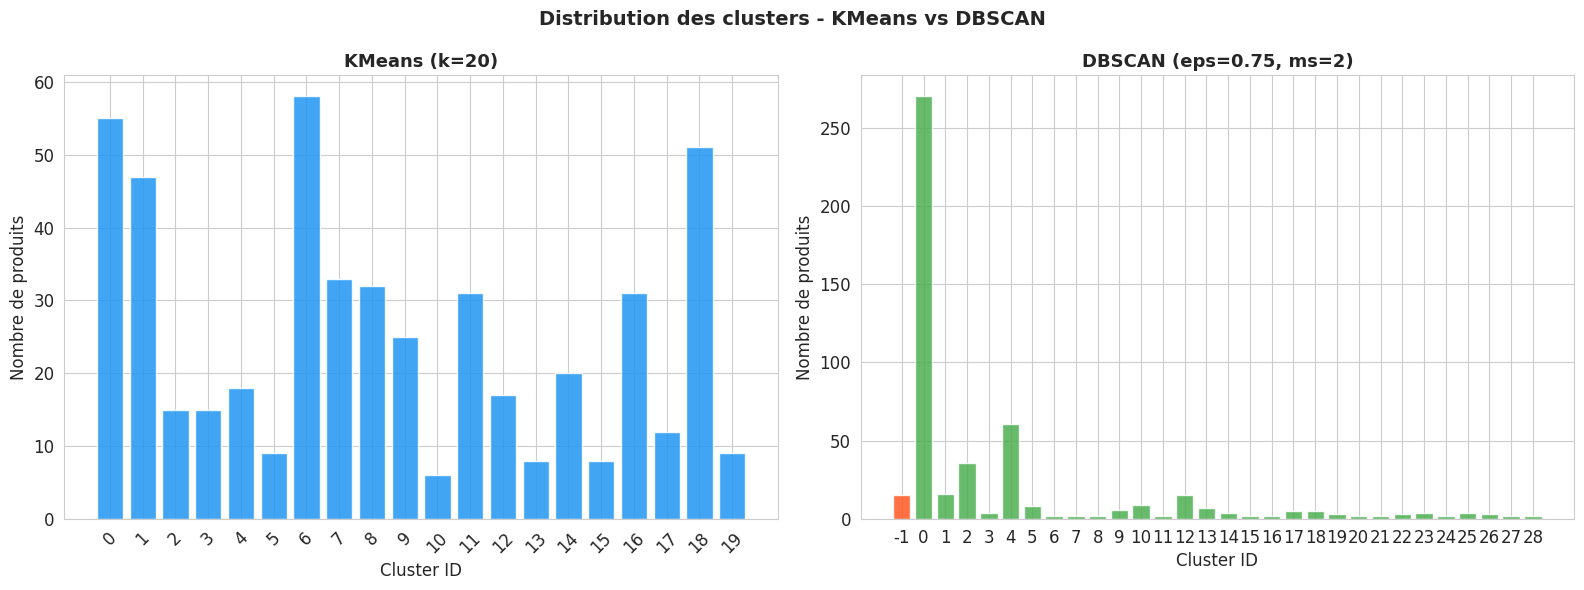

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# KMeans
km_counts = df['cluster_kmeans'].value_counts().sort_index()
axes[0].bar(km_counts.index.astype(str), km_counts.values, color='#2196F3', alpha=0.85)
axes[0].set_title(f'KMeans (k={best_k})', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Cluster ID')
axes[0].set_ylabel('Nombre de produits')
axes[0].tick_params(axis='x', rotation=45)

# DBSCAN
db_counts = df['cluster_dbscan'].value_counts().sort_index()
colors = ['#FF5722' if c == -1 else '#4CAF50' for c in db_counts.index]
axes[1].bar(db_counts.index.astype(str), db_counts.values, color=colors, alpha=0.85)
axes[1].set_title(f'DBSCAN (eps={eps_best}, ms={ms_best})', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Cluster ID')
axes[1].set_ylabel('Nombre de produits')
axes[1].tick_params(axis='x')

plt.suptitle('Distribution des clusters - KMeans vs DBSCAN', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

fig.savefig(f'{output_image_path}/05_kmeans_vs_dbscan_dist.png')

#### **4.3 Matrice de correspondance KMeans vs DBSCAN**

Vérifions si les deux modèles identifient des groupes similaires.

In [11]:
# Cross-tabulation KMeans vs DBSCAN
cross = pd.crosstab(df['cluster_kmeans'], df['cluster_dbscan'], margins=True)
print(cross.to_string())

cluster_dbscan  -1    0   1   2  3   4  5  6  7  8  9  10  11  12  13  14  15  16  17  18  19  20  21  22  23  24  25  26  27  28  All
cluster_kmeans                                                                                                                        
0                0    0   0   0  0  55  0  0  0  0  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   55
1                7   33   0   0  0   0  0  0  0  0  0   0   0   0   0   4   0   0   1   0   0   0   0   1   0   0   0   0   0   1   47
2                0   15   0   0  0   0  0  0  0  0  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   15
3                0    0   0   0  0   0  0  0  0  0  0   0   0  15   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   15
4                0   15   0   0  0   0  0  0  0  0  0   0   0   0   0   0   0   0   0   0   3   0   0   0   0   0   0   0   0   0   18
5                0    0   9   0  0   0  0  0  0  0  0  

#### **4.4 Conclusion sur le clustering**

**DBSCAN avec métrique cosinus** est le meilleur choix pour ce projet car :
1. La distance cosinus est la norme pour les données textuelles TF-IDF
2. La détection des outliers évite de polluer les clusters avec des produits atypiques
3. Pas besoin de deviner k à l'avance

On utilise les clusters DBSCAN pour le système de recommandation.

### **5. Système de Recommandation**

Mon approche **hybride** combine :
1. **Cluster membership** (DBSCAN): les produits du même cluster sont similaires
2. **Cosine similarity** (TF-IDF): pour **classer** les produits similaires du plus au moins pertinent

C'est une amélioration par rapport à un recommandeur cluster-only qui retournerait des produits aléatoires du même cluster.

In [12]:
def find_similar_items(item_id, df=df, tfidf_matrix=tfidf_matrix, n=5):
    """
    Système de recommandation hybride : Cluster-based + Cosine Similarity.
    
    Algorithme :
    1. Trouver le cluster du produit cible
    2. Si le produit est dans un cluster → chercher dans le même cluster, 
       classer par similarité cosinus
    3. Si outlier (cluster=-1) → pure similarité cosinus sur tout le catalogue
    4. Si pas assez de produits dans le cluster → compléter avec les plus similaires
    
    Parameters
    ----------
    item_id : int
        ID du produit
    n : int
        Nombre de recommandations à retourner
    
    Returns
    -------
    pd.DataFrame : les N produits les plus similaires
    """
    # Trouver l'index du produit
    idx_matches = df.index[df['id'] == item_id]
    if len(idx_matches) == 0:
        print(f"Produit ID {item_id} introuvable dans le catalogue !")
        return None
    
    idx = idx_matches[0]
    product_cluster = df.loc[idx, 'cluster_dbscan']
    desc_preview = df.loc[idx, 'description'][:80]
    
    print(f"Produit ID {item_id} : \"{desc_preview}...\"")
    print(f"Cluster DBSCAN : {product_cluster}")
    
    # Similarité cosinus avec tous les produits
    sims = cosine_similarity(tfidf_matrix[idx], tfidf_matrix).flatten()
    sims[idx] = -1  # Exclure le produit lui-même
    
    if product_cluster != -1:
        # Chercher dans le même cluster, trié par similarité
        same_cluster = df.index[df['cluster_dbscan'] == product_cluster].tolist()
        same_cluster = [i for i in same_cluster if i != idx]
        
        if len(same_cluster) >= n:
            ranked = sorted(same_cluster, key=lambda i: sims[i], reverse=True)
            top_indices = ranked[:n]
        else:
            # Compléter avec les plus similaires hors cluster
            top_indices = sorted(same_cluster, key=lambda i: sims[i], reverse=True)
            all_sorted = np.argsort(sims)[::-1]
            for i in all_sorted:
                if i not in top_indices and i != idx:
                    top_indices.append(i)
                    if len(top_indices) == n:
                        break
    else:
        # Outlier: pure similarité
        top_indices = np.argsort(sims)[::-1][:n].tolist()
    
    # Construire les résultats
    results = []
    for rank, i in enumerate(top_indices, 1):
        results.append({
            'Rank': rank,
            'ID': df.loc[i, 'id'],
            'Cluster': df.loc[i, 'cluster_dbscan'],
            'Similarité': round(sims[i], 4),
            'Description': df.loc[i, 'description'][:90] + '...'
        })
    
    return pd.DataFrame(results)

In [13]:
# Test avec plusieurs types de produits
test_ids = [1, 14, 35, 42, 7, 100, 250]

for tid in test_ids:
    if tid in df['id'].values:
        print(f"\n{'-'*10}")
        recs = find_similar_items(tid)
        if recs is not None:
            print(f"\nRecommandations :")
            print(recs.to_string(index=False))


----------
Produit ID 1 : "Active classic boxers - There's a reason why our boxers are a cult favorite - th..."
Cluster DBSCAN : 0

Recommandations :
 Rank  ID  Cluster  Similarité                                                                                   Description
    1 494        0      0.3882 Active boxer briefs - A no-fuss travel companion, these skivvies love sink and creek baths...
    2  19        0      0.3806 Cap 1 boxer briefs - On bivy or belay, the form-fitting Capilene 1 Boxer Briefs stay dry a...
    3 495        0      0.3708 Active briefs - These featherweight, quick-wicking briefs keep you comfortable and dry whe...
    4  18        0      0.2968 Cap 1 bottoms - Spring skiing is as transient as the wind. Move fast, move light, and stil...
    5  25        0      0.2805 Cap 4 bottoms - For sufferfests like the Grand in January, a pair of these warm bottoms wi...

----------
Produit ID 14 : "Better sweater jkt - June nights camped out in New Mexico's Navajo cou

In [14]:
# Similarité moyenne des recommandations vs aléatoire
print(f"\nSimilarité cosinus moyenne :")
sample_sims_rec = []
sample_sims_random = []

np.random.seed(42)
for _ in range(100):
    i = np.random.randint(0, len(df))
    sims = cosine_similarity(tfidf_matrix[i], tfidf_matrix).flatten()
    sims[i] = -1
    top5 = np.argsort(sims)[::-1][:5]
    sample_sims_rec.append(np.mean([sims[j] for j in top5]))
    rand5 = np.random.choice([x for x in range(len(df)) if x != i], 5, replace=False)
    sample_sims_random.append(np.mean([sims[j] for j in rand5]))

print(f"Recommandations top-5 : {np.mean(sample_sims_rec):.4f}")
print(f"Sélection aléatoire   : {np.mean(sample_sims_random):.4f}")
print(f"Amélioration : x{np.mean(sample_sims_rec)/np.mean(sample_sims_random):.1f}")


Similarité cosinus moyenne :
Recommandations top-5 : 0.4347
Sélection aléatoire   : 0.0443
Amélioration : x9.8


### **6. Topic Modeling - LSA (TruncatedSVD)**

#### **6.1 Choix du nombre de topics - Variance expliquée**

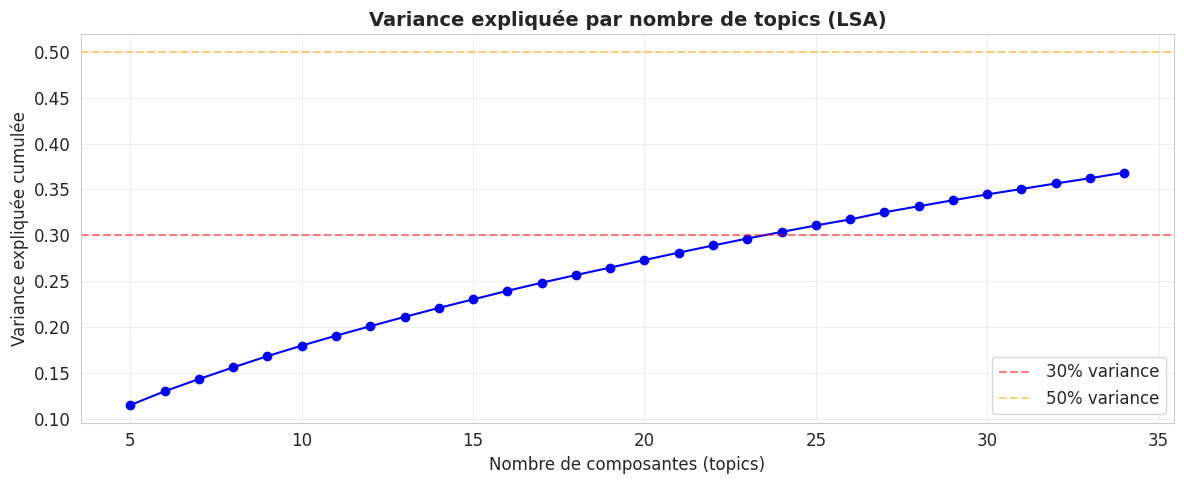

On cherche le coude : au-delà, les topics supplémentaires apportent peu.
Un bon compromis entre interprétabilité (10-20) et variance est visé.


In [15]:
# Variance expliquée en fonction du nombre de composantes
n_range = range(5, 35)
explained_vars = []

for n in n_range:
    svd = TruncatedSVD(n_components=n, random_state=42)
    svd.fit(tfidf_matrix)
    explained_vars.append(svd.explained_variance_ratio_.sum())

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(list(n_range), explained_vars, 'b-o', markersize=6)
ax.set_xlabel('Nombre de composantes (topics)')
ax.set_ylabel('Variance expliquée cumulée')
ax.set_title('Variance expliquée par nombre de topics (LSA)', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.axhline(y=0.3, color='r', linestyle='--', alpha=0.5, label='30% variance')
ax.axhline(y=0.5, color='orange', linestyle='--', alpha=0.5, label='50% variance')
ax.legend()
plt.tight_layout()
plt.show()

print("On cherche le coude : au-delà, les topics supplémentaires apportent peu.")
print("Un bon compromis entre interprétabilité (10-20) et variance est visé.")

#### **6.2 Entraînement du modèle LSA**

In [16]:
# Choisir n_components = 15 (bon compromis dans la plage 10-20)
n_topics = 15

svd_model = TruncatedSVD(n_components=n_topics, random_state=42, algorithm='randomized')
topic_encoded_df = svd_model.fit_transform(tfidf_matrix)

print(f"Modèle LSA entraîné avec {n_topics} topics")
print(f"Matrice topic_encoded_df : {topic_encoded_df.shape}")
print(f"Variance expliquée totale : {svd_model.explained_variance_ratio_.sum()*100:.1f}%")
print(f"\nVariance par topic :")
for i, v in enumerate(svd_model.explained_variance_ratio_):
    print(f"- Topic {i:2d} : {v*100:5.1f}%")

Modèle LSA entraîné avec 15 topics
Matrice topic_encoded_df : (500, 15)
Variance expliquée totale : 23.0%

Variance par topic :
- Topic  0 :   1.9%
- Topic  1 :   3.4%
- Topic  2 :   2.5%
- Topic  3 :   1.9%
- Topic  4 :   1.8%
- Topic  5 :   1.5%
- Topic  6 :   1.3%
- Topic  7 :   1.3%
- Topic  8 :   1.2%
- Topic  9 :   1.2%
- Topic 10 :   1.1%
- Topic 11 :   1.0%
- Topic 12 :   1.0%
- Topic 13 :   1.0%
- Topic 14 :   0.9%


#### **6.3 Analyse des topics - Top mots**

In [17]:
def get_top_words(component, feature_names, n=10):
    """Extraire les mots les plus importants d'un topic."""
    top_idx = component.argsort()[::-1][:n]
    return [(feature_names[i], round(component[i], 4)) for i in top_idx]

for topic_idx, component in enumerate(svd_model.components_):
    top = get_top_words(component, feature_names, 8)
    words_str = ' - '.join([f"{w} ({s:.3f})" for w, s in top])
    var = svd_model.explained_variance_ratio_[topic_idx] * 100
    print(f"Topic {topic_idx:2d} [{var:4.1f}%] : {words_str}")

Topic  0 [ 1.9%] : organic (0.177) - shirt (0.173) - recycle (0.160) - tap shoulder (0.157) - tap (0.156) - shoulder seam (0.154) - thread recycle (0.154) - thread (0.154)
Topic  1 [ 3.4%] : pocket (0.148) - dwr (0.113) - water (0.111) - durable (0.101) - zipper (0.101) - finish (0.100) - repellent (0.097) - water repellent (0.097)
Topic  2 [ 2.5%] : odor (0.163) - merino (0.137) - control (0.127) - wool (0.118) - merino wool (0.104) - gladiodor (0.103) - natural odor (0.103) - odor control (0.103)
Topic  3 [ 1.9%] : merino (0.171) - wool (0.147) - merino wool (0.130) - resist odor (0.097) - cold lie (0.097) - wash cold (0.097) - flat dry (0.097) - slow wash (0.097)
Topic  4 [ 1.8%] : organic (0.188) - button (0.163) - short (0.126) - zip fly (0.125) - button closure (0.119) - fly (0.106) - closure (0.105) - organic canvas (0.101)
Topic  5 [ 1.5%] : photo (0.219) - poster (0.171) - outside (0.161) - space inspire (0.107) - excited select (0.107) - speak passion (0.107) - specialty outd

#### **6.4 Topic principal par document**

Distribution des topics principaux :


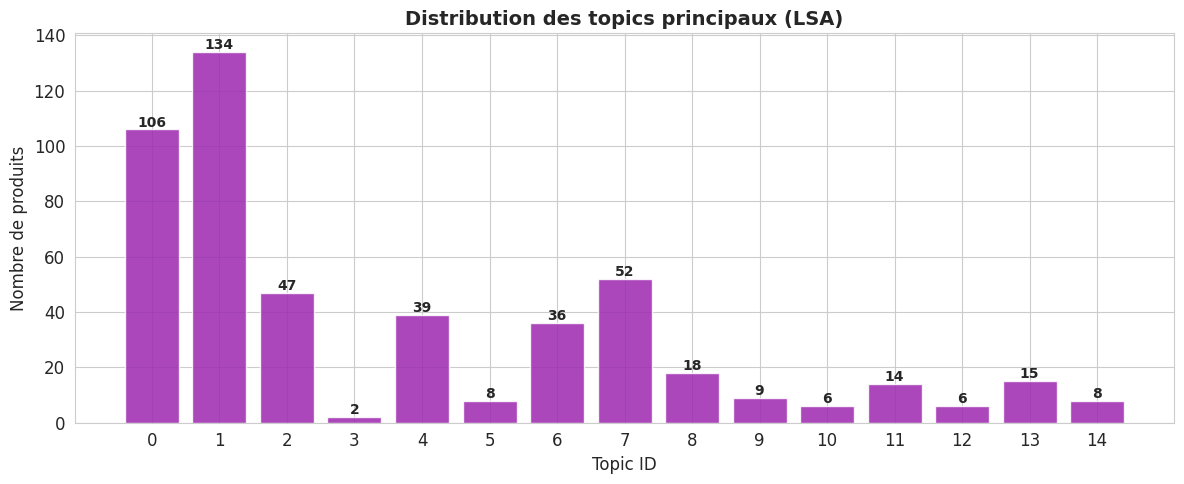

In [18]:
# Assigner le topic principal (composante avec le poids le plus élevé)
df['main_topic'] = topic_encoded_df.argmax(axis=1)

print("Distribution des topics principaux :")
topic_dist = df['main_topic'].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.bar(topic_dist.index.astype(str), topic_dist.values, color='#9C27B0', alpha=0.85)
ax.set_xlabel('Topic ID')
ax.set_ylabel('Nombre de produits')
ax.set_title('Distribution des topics principaux (LSA)', fontsize=14, fontweight='bold')

# Annoter les barres
for bar, val in zip(bars, topic_dist.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            str(val), ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

fig.savefig(f'{output_image_path}/06_lsa_topic_dist.png')

#### **6.5 WordClouds - Topics LSA**

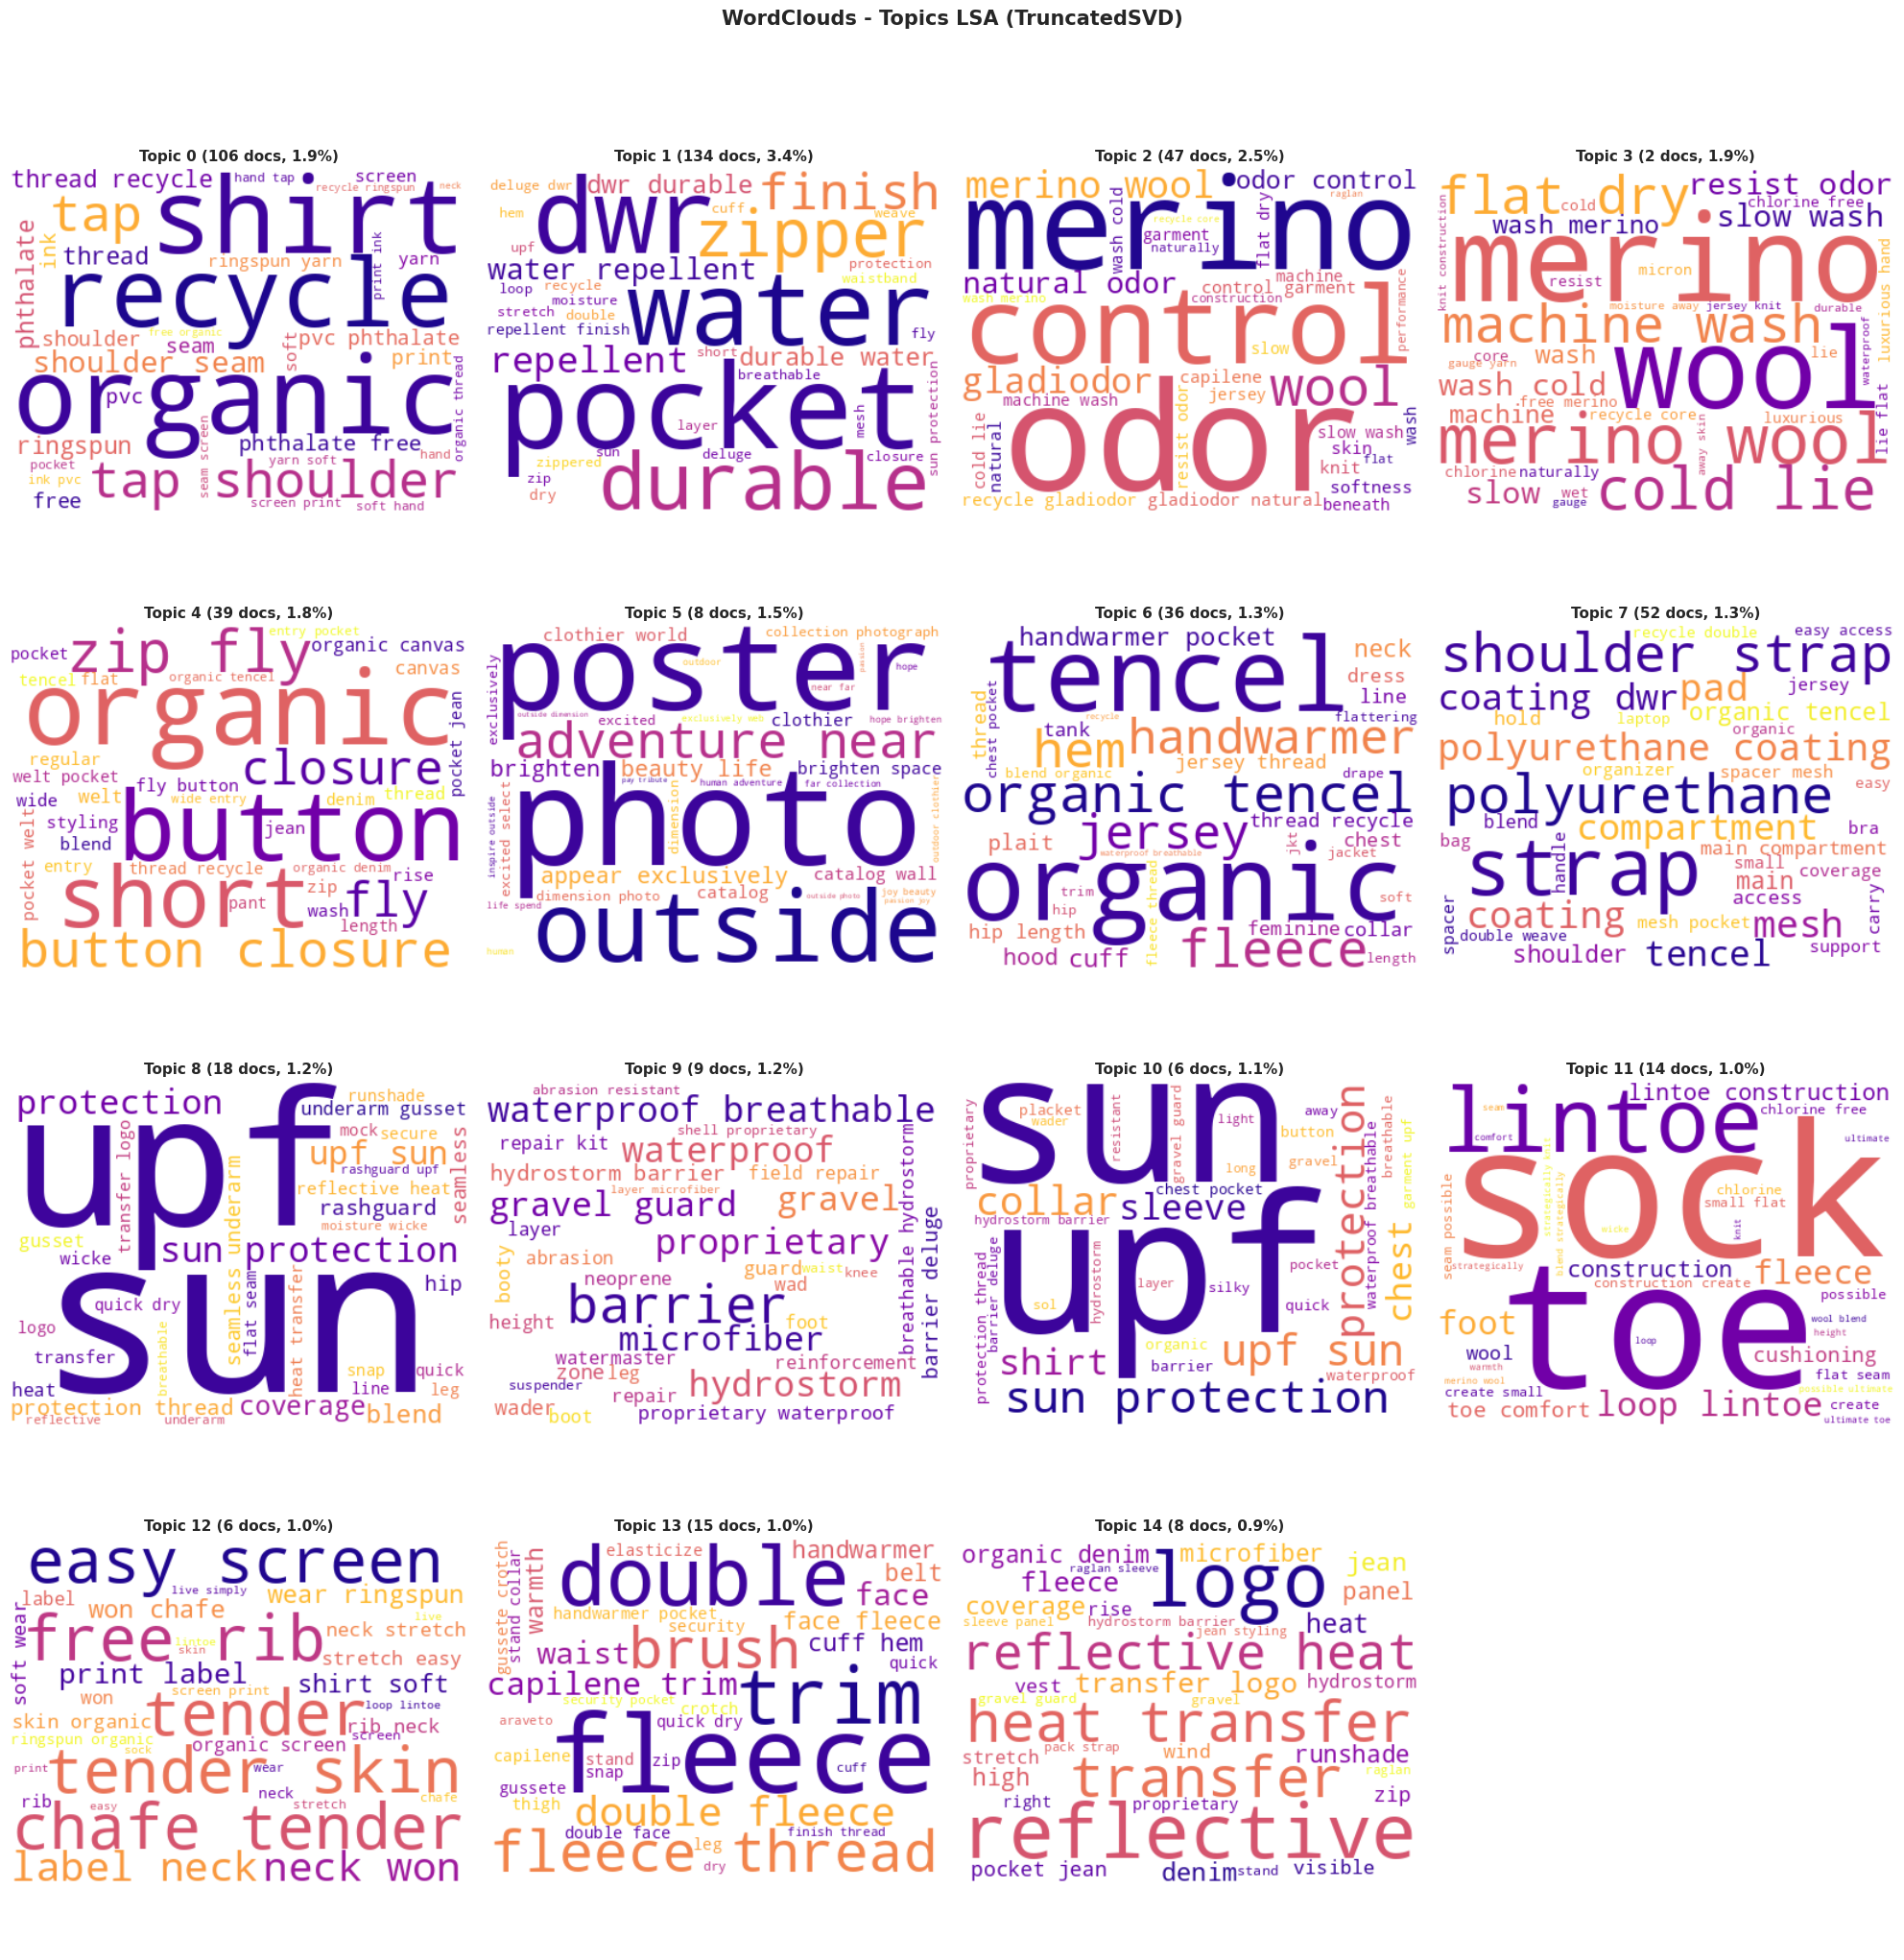

In [19]:
# WordClouds basés sur les poids des composantes SVD
n_show = min(n_topics, 16)
cols = 4
rows = (n_show + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(20, 5 * rows))
axes = axes.flatten()

for topic_idx in range(n_show):
    component = svd_model.components_[topic_idx]
    word_weights = {feature_names[i]: w for i, w in enumerate(component) if w > 0}
    
    if word_weights:
        wc = WordCloud(width=400, height=300, background_color='white',
                       max_words=35, colormap='plasma', random_state=42
                      ).generate_from_frequencies(word_weights)
        axes[topic_idx].imshow(wc, interpolation='bilinear')
    
    n_docs = (df['main_topic'] == topic_idx).sum()
    var = svd_model.explained_variance_ratio_[topic_idx] * 100
    axes[topic_idx].set_title(f'Topic {topic_idx} ({n_docs} docs, {var:.1f}%)', 
                               fontsize=11, fontweight='bold')
    axes[topic_idx].axis('off')

for idx in range(n_show, len(axes)):
    axes[idx].axis('off')

plt.suptitle('WordClouds - Topics LSA (TruncatedSVD)', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

fig.savefig(f'{output_image_path}/07_lsa_wordclouds.png')

### **7. Comparaison globale & Conclusion**

#### **7.1 Clusters DBSCAN vs Topics LSA**

Matrice de croisement Clusters DBSCAN vs Topics LSA :
main_topic        0    1   2  3   4  5   6   7   8  9  10  11  12  13  14  All
cluster_dbscan                                                                
-1                8    3   0  0   1  0   0   1   1  0   0   0   0   1   0   15
0                28   98  34  0  30  0  34  15  11  1   6   0   0  13   0  270
1                 0   13   0  0   0  0   0   0   0  0   0   0   0   0   3   16
2                 0    2   0  0   0  0   0  26   0  8   0   0   0   0   0   36
3                 1    2   0  0   0  0   0   0   0  0   0   0   0   1   0    4
4                55    0   0  0   0  0   0   0   0  0   0   0   6   0   0   61
5                 0    0   0  0   0  8   0   0   0  0   0   0   0   0   0    8
6                 0    0   0  0   0  0   0   2   0  0   0   0   0   0   0    2
7                 0    2   0  0   0  0   0   0   0  0   0   0   0   0   0    2
8                 0    2   0  0   0  0   0   0   0  0   0   0   0   0   0    

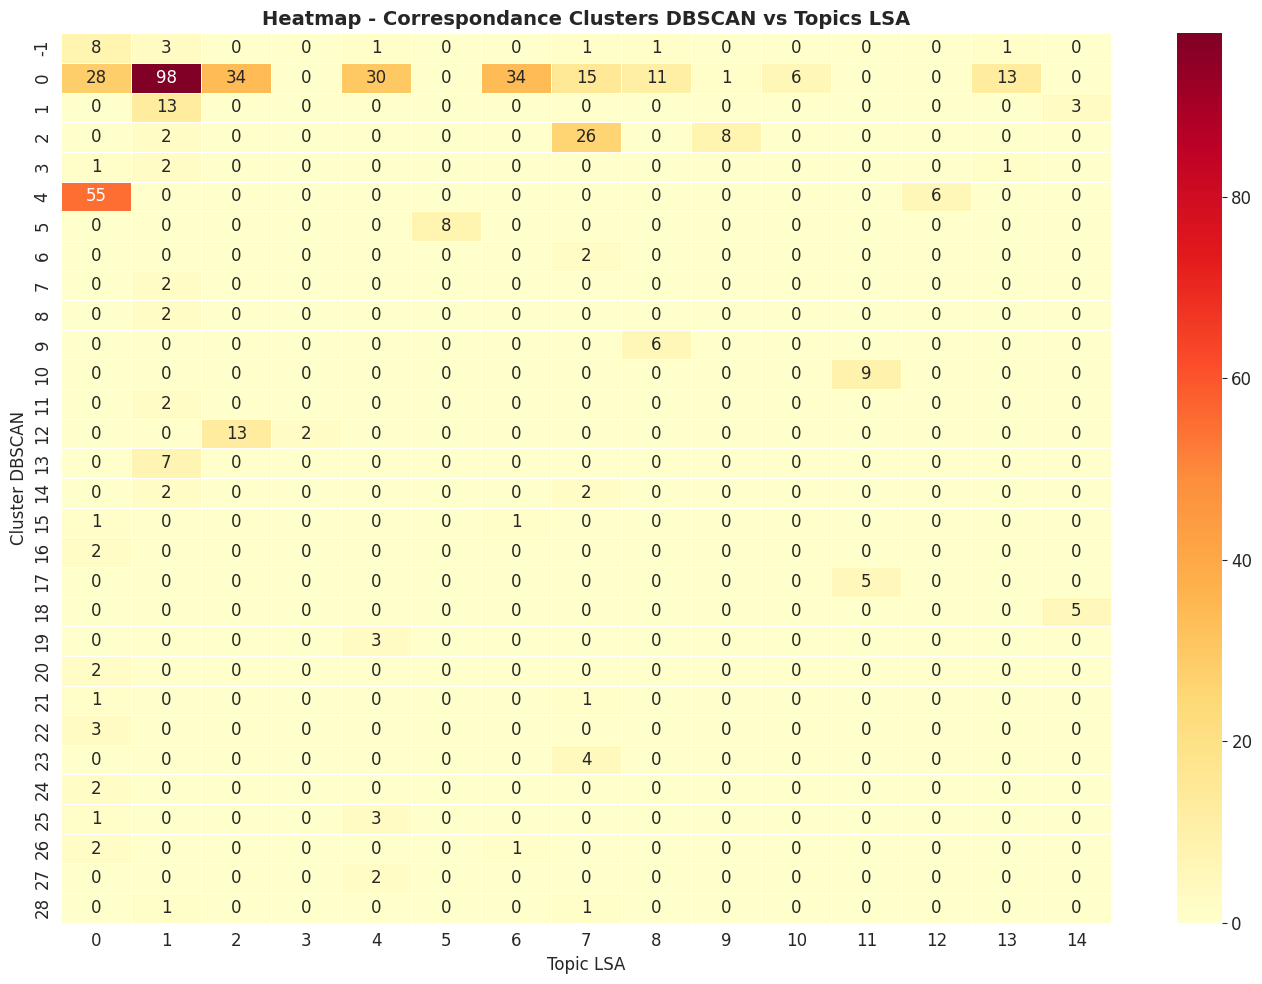

In [20]:
# Cross-tabulation
cross = pd.crosstab(df['cluster_dbscan'], df['main_topic'], margins=True)
print("Matrice de croisement Clusters DBSCAN vs Topics LSA :")
print(cross.to_string())

# Heatmap
fig, ax = plt.subplots(figsize=(14, 10))
cross_no_margins = pd.crosstab(df['cluster_dbscan'], df['main_topic'])
sns.heatmap(cross_no_margins, annot=True, fmt='d', cmap='YlOrRd', ax=ax,
            linewidths=0.5, linecolor='white')
ax.set_xlabel('Topic LSA', fontsize=12)
ax.set_ylabel('Cluster DBSCAN', fontsize=12)
ax.set_title('Heatmap - Correspondance Clusters DBSCAN vs Topics LSA', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

fig.savefig(f'{output_image_path}/08_dbscan_lsa_cross.png')

#### **7.2 Tableau récapitulatif**

In [21]:
print("""
RÉCAPITULATIF DU PROJET        

- DONNÉES                                                        
    - 500 produits The North Face                                   
    - TF-IDF : 5000 features (unigrams + bigrams)    

- PART 1. CLUSTERING                                           
    - Baseline KMeans : {km_k} clusters                            
    - DBSCAN (cosinus) : {db_n} clusters + {db_o} outliers        
    - DBSCAN est plus adapté aux données textuelles      

- PART 2. RECOMMENDATION                                       
    - Méthode hybride : Cluster + Cosine Similarity                
    - Recommandations ~{improve}x plus pertinentes que l'aléatoire 

- PART 3. TOPIC MODELING (LSA)                                  
    - {n_t} topics, {var_t:.1f}% variance expliquée                
    - Chaque produit = mélange de plusieurs topics                  
    - Catégories identifiées : vêtements techniques, outdoor,      
    - fleece, merino, sacs/bagages, protection solaire, etc.        
""".format(
    km_k=best_k,
    db_n=n_clusters,
    db_o=n_outliers,
    improve=f"{np.mean(sample_sims_rec)/np.mean(sample_sims_random):.1f}" if 'sample_sims_rec' in dir() else "N/A",
    n_t=n_topics,
    var_t=svd_model.explained_variance_ratio_.sum()*100
))


RÉCAPITULATIF DU PROJET        

- DONNÉES                                                        
    - 500 produits The North Face                                   
    - TF-IDF : 5000 features (unigrams + bigrams)    

- PART 1. CLUSTERING                                           
    - Baseline KMeans : 20 clusters                            
    - DBSCAN (cosinus) : 29 clusters + 15 outliers        
    - DBSCAN est plus adapté aux données textuelles      

- PART 2. RECOMMENDATION                                       
    - Méthode hybride : Cluster + Cosine Similarity                
    - Recommandations ~9.8x plus pertinentes que l'aléatoire 

- PART 3. TOPIC MODELING (LSA)                                  
    - 15 topics, 23.0% variance expliquée                
    - Chaque produit = mélange de plusieurs topics                  
    - Catégories identifiées : vêtements techniques, outdoor,      
    - fleece, merino, sacs/bagages, protection solaire, etc.        

